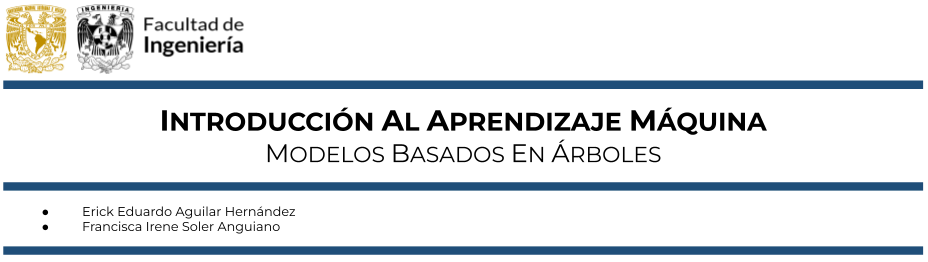

**Repositorio oficial del libro**

https://github.com/ErickEduardoAH/book-resources

**Licencia**

MIT License

---
Este notebook forma parte del material oficial que acompaña al libro *Introducción al Aprendizaje Máquina: Modelos Basados en Árboles*. Su objetivo es reproducir y ampliar los ejemplos desarrollados en el texto mediante implementaciones en Python completamente reproducibles.
___
#### Notebook 7.2.1 — Implementación: random forest en regresión
___

### Preparación del entorno de trabajo

En esta celda se importan las bibliotecas necesarias para estudiar **random forest** en problemas de clasificación y regresión. Además de las herramientas usuales para manipular datos y producir gráficas, se preparan utilidades de `scikit-learn` para dividir muestras, transformar variables categóricas y evaluar modelos. Esta preparación deja listo el entorno para analizar cómo un bosque aleatorio combina muchos árboles y añade aleatoriedad en la selección de predictores para reducir la variabilidad del modelo.


In [1]:
from sklearn.model_selection import train_test_split
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('ggplot')

## Conjunto de datos: Palmer Penguins

En este ejemplo se empleará el conjunto de datos **Palmer Penguins**, el cual contiene mediciones morfológicas de tres especies de pingüinos observadas en el archipiélago Palmer, en la Antártida. Este conjunto de datos fue desarrollado como una alternativa moderna al clásico conjunto **Iris**, proporcionando un problema de clasificación multiclase más realista y con variables de fácil interpretación.

El objetivo consiste en predecir la especie de cada pingüino a partir de sus características físicas.

### Variables predictoras

| Variable | Descripción |
|----------|-------------|
| `bill_length_mm` | Longitud del pico, medida en milímetros. |
| `bill_depth_mm` | Profundidad del pico, medida en milímetros. |
| `flipper_length_mm` | Longitud de la aleta, medida en milímetros. |
| `body_mass_g` | Masa corporal del pingüino, expresada en gramos. |
| `sex` | Sexo del ejemplar (Female o Male). |

### Variable respuesta

| Variable | Descripción |
|----------|-------------|
| `species` | Especie del pingüino. Puede tomar los valores **Adelie**, **Chinstrap** o **Gentoo**. |

### Observaciones

- Cada fila del conjunto de datos corresponde a un pingüino individual.
- Las variables predictoras describen características morfológicas y biológicas de cada ejemplar.
- El conjunto presenta un pequeño número de valores faltantes, los cuales se eliminarán en este ejemplo para simplificar el análisis.
- Debido a que las especies presentan diferencias físicas apreciables, este conjunto de datos es ampliamente utilizado para ilustrar algoritmos de clasificación supervisada y análisis exploratorio de datos.

El conjunto de datos Palmer Penguins fue recopilado por la Dra. Kristen Gorman dentro del programa Long Term Ecological Research (LTER) de la estación Palmer, en la Antártida. En la actualidad constituye una de las alternativas más populares al conjunto de datos Iris, ya que ofrece un problema de clasificación más realista y con variables de interpretación sencilla.

### Carga local del conjunto Palmer Penguins

Se carga el conjunto **Palmer Penguins** desde el archivo `penguins.csv` guardado en el directorio `datos`. Al leer el archivo localmente se evita depender de descargas externas durante la ejecución del notebook. La columna `year` se elimina porque no se usará como predictor en este ejemplo, y las demás columnas se conservan para construir el problema de clasificación multiclase donde la respuesta es `species`.


In [2]:
data_paths = [Path("datos") / "penguins.csv", Path("..") / "datos" / "penguins.csv"]
data_path = next(path for path in data_paths if path.exists())
penguins_data_df = pd.read_csv(data_path).drop(columns=["year"])
feature_names = penguins_data_df.drop(columns="species").columns.tolist()
penguins_data_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male


### Revisión de tipos de datos y valores disponibles

La función `info()` resume el número de observaciones, los tipos de variables y la presencia de valores faltantes. Esta revisión es útil antes de ajustar el modelo porque permite distinguir variables numéricas de categóricas y anticipar el tratamiento necesario para que el bosque aleatorio reciba una matriz de predictores adecuada.


In [3]:
penguins_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


### Eliminación de valores faltantes

Dado que el conjunto de datos presenta un número reducido de observaciones con valores faltantes, en este ejemplo se eliminarán dichos registros para simplificar el análisis. En aplicaciones reales podrían emplearse técnicas de imputación cuando la cantidad de datos faltantes sea considerable, especialmente si eliminar filas implica perder información relevante.


In [4]:
penguins_data_df = penguins_data_df.dropna()

### Codificación de predictores categóricos

Los modelos de `scikit-learn` requieren predictores numéricos. Por ello, las variables categóricas `sex` e `island` se transforman mediante codificación one-hot, creando columnas indicadoras para sus categorías. Las variables morfológicas numéricas pasan sin modificación. El resultado es una matriz `X` completamente numérica, lista para entrenar el bosque aleatorio.


In [5]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

categoricals = [
    "sex",
    "island",
]

numericals = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

ohe = OneHotEncoder(
    drop=None,           # no elimina categorías
    sparse_output=False, # devuelve DataFrame usable
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, categoricals),
        ("num", "passthrough", numericals)
    ]
)

X_transformed = preprocessor.fit_transform(penguins_data_df)

cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categoricals)

all_features = list(cat_features) + numericals

X = pd.DataFrame(X_transformed, columns=all_features)

display(X)

,sex_female,sex_male,island_Biscoe,island_Dream,island_Torgersen,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,0.0,1.0,0.0,0.0,1.0,39.1,18.7,181.0,3750.0
1,1.0,0.0,0.0,0.0,1.0,39.5,17.4,186.0,3800.0
2,1.0,0.0,0.0,0.0,1.0,40.3,18.0,195.0,3250.0
3,1.0,0.0,0.0,0.0,1.0,36.7,19.3,193.0,3450.0
4,0.0,1.0,0.0,0.0,1.0,39.3,20.6,190.0,3650.0
...,...,...,...,...,...,...,...,...,...
328,0.0,1.0,0.0,1.0,0.0,55.8,19.8,207.0,4000.0
329,1.0,0.0,0.0,1.0,0.0,43.5,18.1,202.0,3400.0
330,0.0,1.0,0.0,1.0,0.0,49.6,18.2,193.0,3775.0
331,0.0,1.0,0.0,1.0,0.0,50.8,19.0,210.0,4100.0


### Codificación de la variable respuesta

En este caso la variable `species` es la respuesta del problema de clasificación, por lo que `LabelEncoder` es una herramienta apropiada para convertir sus categorías en etiquetas numéricas. Para las variables predictoras categóricas, como `sex` o `island`, se prefiere `OneHotEncoder` porque asignar enteros introduciría un orden artificial entre categorías que no son ordinales.


In [6]:
from sklearn.preprocessing import LabelEncoder

species_encoder = LabelEncoder().fit(penguins_data_df["species"])
y = species_encoder.transform(penguins_data_df["species"])
print(dict(zip(species_encoder.classes_, species_encoder.transform(species_encoder.classes_))))
print(y)

{'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


### Separación estratificada en entrenamiento y prueba

El conjunto Palmer Penguins se divide en una muestra de entrenamiento y una muestra de prueba. La opción `stratify=y` conserva la proporción de especies en ambos subconjuntos, lo que permite evaluar el modelo en una muestra de prueba representativa del problema original. Esta separación es esencial para medir desempeño fuera de muestra.


In [7]:
from sklearn.model_selection import train_test_split

X_train_penguins, X_test_penguins, y_train_penguins, y_test_penguins = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=123)

### Ajuste de un random forest para clasificación

Se ajusta un `RandomForestClassifier` para predecir la especie de los pingüinos. Un random forest combina varios árboles de decisión entrenados sobre muestras bootstrap y, además, introduce aleatoriedad al considerar subconjuntos de predictores en las particiones. Después del ajuste se evalúa el modelo en el conjunto de prueba mediante una matriz de confusión, que muestra cuántas observaciones de cada especie fueron clasificadas correctamente o confundidas con otra especie.


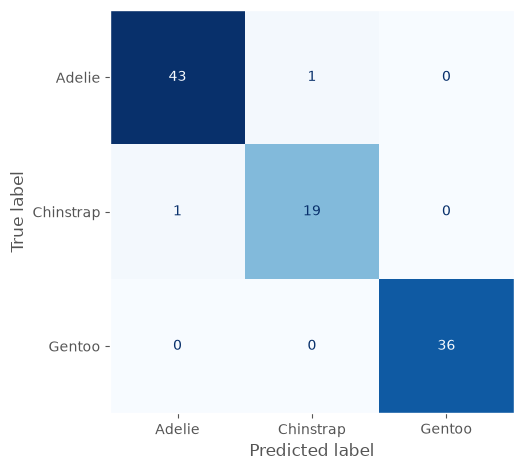

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

rf_penguins = RandomForestClassifier(
    n_estimators=3,
    random_state=41
).fit(X_train_penguins,y_train_penguins)


y_pred = rf_penguins.predict(X_test_penguins)
cm_df = pd.DataFrame(
    confusion_matrix(y_test_penguins, y_pred),
    index=species_encoder.classes_,
    columns=species_encoder.classes_
)

ConfusionMatrixDisplay.from_estimator(
    rf_penguins,
    X_test_penguins,
    y_test_penguins,
    display_labels=species_encoder.classes_,
    cmap="Blues",
    values_format="d",
    colorbar=False
)
plt.grid(False)
plt.tight_layout()

### AUC multiclase por especie

En este conjunto de datos, incluso un bosque formado por únicamente tres árboles alcanza un desempeño muy elevado. Esto sugiere que las especies de pingüinos pueden separarse eficazmente a partir de las variables morfológicas consideradas. Para complementar la matriz de confusión, se calcula el AUC bajo el esquema uno contra el resto: cada especie se evalúa como clase positiva frente a las demás. En aplicaciones más complejas, incrementar el número de árboles suele mejorar la estabilidad del modelo, aunque después de cierto punto las ganancias son marginales.


<Axes: ylabel='AUC'>

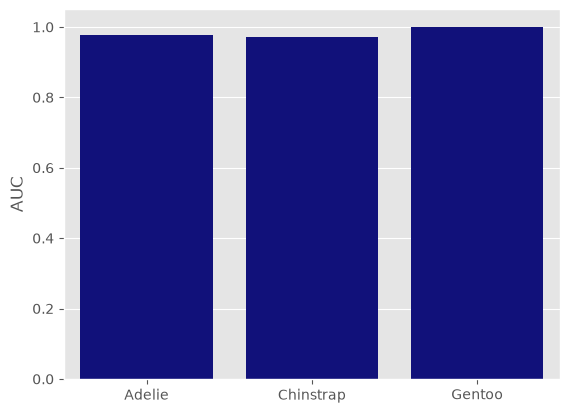

In [9]:
from sklearn.metrics import roc_auc_score

y_score = rf_penguins.predict_proba(X_test_penguins)
auc_vector = roc_auc_score(
    y_test_penguins,
    y_score,
    multi_class="ovr",
    average=None
)

auc_vector_df = pd.Series(
    auc_vector,
    index=species_encoder.classes_,
    name="AUC"
)
sns.barplot(auc_vector_df,color='darkblue')

<Axes: xlabel='importance', ylabel='variable'>

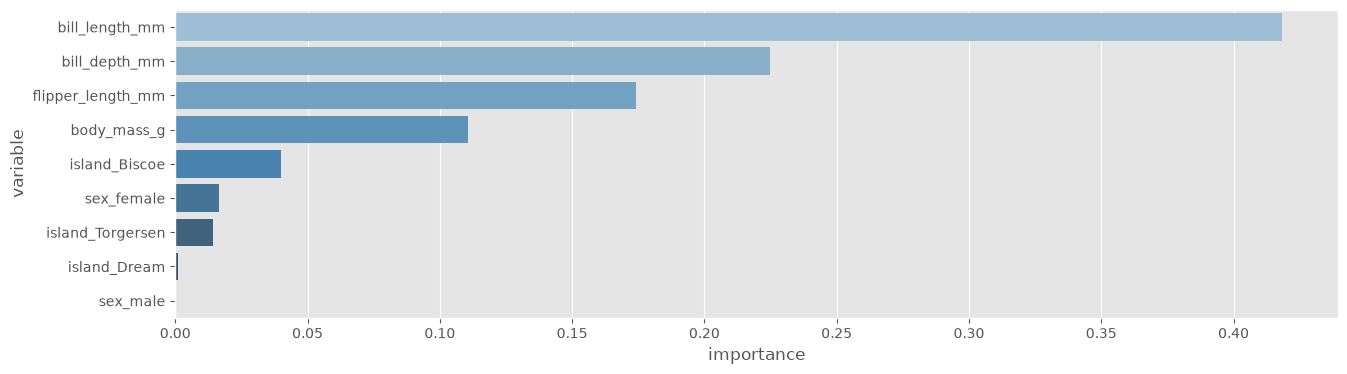

In [10]:
importances_df = pd.DataFrame([X_train_penguins.columns,
                               rf_penguins.feature_importances_])\
                   .transpose()
importances_df.columns = ['variable','importance']
importances_df.sort_values('importance',ascending=False,inplace=True)


plt.figure(figsize=(15,4))
sns.barplot(y="variable",
            x="importance",
            data=importances_df,
            palette="Blues_d")

___
#### Notebook 7.2.2 — Implementación: random forest en regresión
___

## Conjunto de datos: Diamonds

En este ejemplo se utilizará el conjunto de datos **Diamonds**, uno de los conjuntos de datos de regresión más empleados para ilustrar técnicas de aprendizaje automático. Contiene información sobre las características físicas y de calidad de miles de diamantes, así como su precio de venta.

El objetivo consiste en construir un modelo capaz de predecir el **precio** de un diamante a partir de sus características gemológicas y sus dimensiones físicas.

### Variables predictoras

| Variable | Descripción |
|----------|-------------|
| `carat` | Peso del diamante, expresado en quilates (1 quilate = 0.2 gramos). |
| `cut` | Calidad del corte del diamante. Las categorías son: *Fair*, *Good*, *Very Good*, *Premium* e *Ideal*. |
| `color` | Calidad del color del diamante. Se clasifica desde **D** (mejor calidad) hasta **J**. |
| `clarity` | Grado de pureza del diamante, determinado por la cantidad y visibilidad de inclusiones internas. |
| `depth` | Profundidad total del diamante expresada como porcentaje. |
| `table` | Tamaño de la faceta superior (*table*) expresado como porcentaje del ancho máximo. |
| `x` | Longitud del diamante, en milímetros. |
| `y` | Ancho del diamante, en milímetros. |
| `z` | Altura (profundidad) del diamante, en milímetros. |

### Variable respuesta

| Variable | Descripción |
|----------|-------------|
| `price` | Precio del diamante, expresado en dólares estadounidenses. |

### Preprocesamiento

Las variables categóricas (`cut`, `color` y `clarity`) se transformarán mediante **codificación One-Hot (One-Hot Encoding)** para que puedan ser utilizadas por el modelo de aprendizaje automático.

A diferencia de los modelos lineales, en este ejemplo no se elimina ninguna categoría de referencia (`drop_first=False`), ya que los métodos basados en árboles no presentan problemas de multicolinealidad durante el proceso de entrenamiento.

### Observaciones

- El conjunto de datos contiene **53,940 observaciones**, por lo que resulta adecuado para evaluar algoritmos de ensamble como **Random Forest**.
- Las variables `carat`, `x`, `y` y `z` describen el tamaño físico del diamante y presentan una alta correlación entre sí.
- Debido a esta redundancia, distintas variables pueden aportar información similar al modelo, lo que convierte a este conjunto de datos en un excelente ejemplo para analizar la importancia de las variables y el efecto de la multicolinealidad en métodos basados en árboles.

### Carga local del conjunto Diamonds

Se carga el conjunto **Diamonds** desde el archivo `diamonds.csv` guardado en `datos`. Este conjunto se usará para estudiar random forest en regresión, donde la variable objetivo es `price`. Leer el archivo desde el repositorio mantiene el notebook reproducible y evita depender de fuentes externas durante la ejecución.


In [11]:
data_paths = [Path("datos") / "diamonds.csv", Path("..") / "datos" / "diamonds.csv"]
data_path = next(path for path in data_paths if path.exists())
diamonds_data_df = pd.read_csv(data_path)
diamonds_data_df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


### Revisión de estructura del conjunto Diamonds

Con `info()` se inspeccionan los tipos de datos, el número de observaciones y la presencia de valores faltantes. Esta revisión ayuda a confirmar qué variables requieren codificación one-hot y cuáles pueden pasar directamente como variables numéricas al modelo.


In [12]:
diamonds_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


### Codificación de variables para regresión

Las variables categóricas del diamante, como `cut`, `color` y `clarity`, se transforman mediante one-hot encoding. Las variables numéricas asociadas al tamaño y a la geometría del diamante pasan sin modificación. Con esta transformación se obtiene una matriz de predictores numérica que puede ser usada por el `RandomForestRegressor`, mientras que `price` se conserva como variable respuesta continua.


In [13]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

categoricals = [
    "cut",
    "color",
    "clarity"
]

numericals = [
    "carat",
    "depth",
    "table",
    "x",
    "y",
    "z"
]

ohe = OneHotEncoder(
    drop=None,           # no elimina categorías
    sparse_output=False, # devuelve DataFrame usable
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe, categoricals),
        ("num", "passthrough", numericals)
    ]
)

X_transformed = preprocessor.fit_transform(diamonds_data_df)

cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categoricals)

all_features = list(cat_features) + numericals

X = pd.DataFrame(X_transformed, columns=all_features)
y = diamonds_data_df["price"]
display(X)

,cut_Fair,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,color_D,color_E,color_F,color_G,color_H,...,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2,carat,depth,table,x,y,z
0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.23,61.5,55.0,3.95,3.98,2.43
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.21,59.8,61.0,3.89,3.84,2.31
2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.23,56.9,65.0,4.05,4.07,2.31
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.29,62.4,58.0,4.20,4.23,2.63
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.31,63.3,58.0,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.72,60.8,57.0,5.75,5.76,3.50
53936,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.72,63.1,55.0,5.69,5.75,3.61
53937,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.70,62.8,60.0,5.66,5.68,3.56
53938,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.86,61.0,58.0,6.15,6.12,3.74


### Separación entrenamiento-prueba para Diamonds

El conjunto Diamonds se divide en datos de entrenamiento y datos de prueba. El modelo se ajusta con la muestra de entrenamiento y se evalúa con observaciones no usadas durante el ajuste. En regresión, esta comparación permite estimar qué tan bien generaliza el bosque al predecir precios de diamantes fuera de muestra.


In [14]:
from sklearn.model_selection import train_test_split

X_train_diamonds, X_test_diamonds, y_train_diamonds, y_test_diamonds = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=123)

### Random forest de regresión e importancia de variables

Se ajusta un `RandomForestRegressor` para predecir el precio de los diamantes y se evalúa su desempeño mediante $R^2$ en el conjunto de prueba. Después se calculan las importancias de variables del modelo. En los árboles, una variable recibe mayor importancia cuando sus particiones reducen de forma importante la impureza o el error a lo largo del bosque.


r2_score:  0.9628498977871596


<Axes: xlabel='importance', ylabel='variable'>

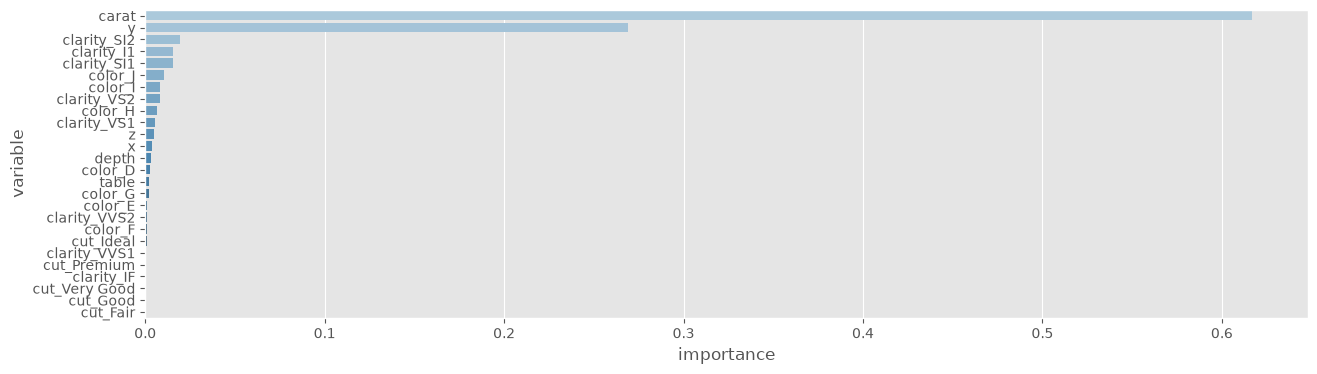

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf_diamonds = RandomForestRegressor(
    n_estimators=1,
    random_state=41
).fit(X_train_diamonds,y_train_diamonds)

y_pred_test_diamonds = rf_diamonds.predict(X_test_diamonds)

print("r2_score: ",r2_score(y_test_diamonds, y_pred_test_diamonds))

importances_df = pd.DataFrame([X.columns,
                               rf_diamonds.feature_importances_])\
                   .transpose()
importances_df.columns = ['variable','importance']
importances_df.sort_values('importance',ascending=False,inplace=True)


plt.figure(figsize=(15,4))
sns.barplot(y="variable",
            x="importance",
            data=importances_df,
            palette="Blues_d")

### Modelo sin la variable `carat`

Para analizar la dependencia del modelo respecto a una variable dominante, se vuelve a ajustar el bosque eliminando `carat` de los predictores. Esta comparación permite observar si el desempeño predictivo cambia de forma importante cuando se retira una variable con alta importancia, o si otras variables relacionadas pueden sustituir parte de su información.


r2_score:  0.9617089913539484


<Axes: xlabel='importance', ylabel='variable'>

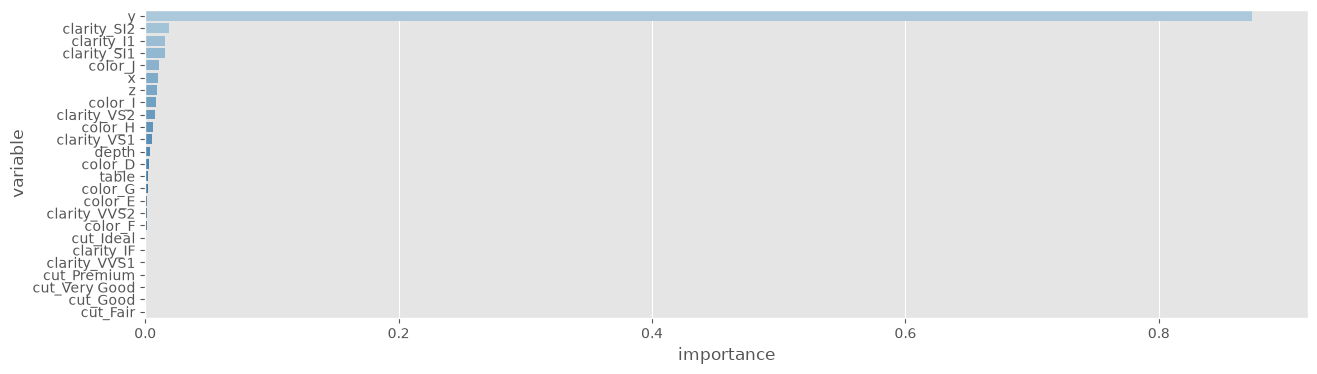

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf_diamonds = RandomForestRegressor(
    n_estimators=1,
    random_state=41
).fit(X_train_diamonds.drop(columns="carat"),y_train_diamonds)

y_pred_test_diamonds = rf_diamonds.predict(X_test_diamonds.drop(columns="carat"))

print("r2_score: ",r2_score(y_test_diamonds, y_pred_test_diamonds))

importances_df = pd.DataFrame([X.drop(columns="carat").columns,
                               rf_diamonds.feature_importances_])\
                   .transpose()
importances_df.columns = ['variable','importance']
importances_df.sort_values('importance',ascending=False,inplace=True)


plt.figure(figsize=(15,4))
sns.barplot(y="variable",
            x="importance",
            data=importances_df,
            palette="Blues_d")

### Correlación entre tamaño del diamante y precio

En este conjunto de datos existe una alta correlación entre las variables `carat`, `x`, `y` y `z`, todas ellas relacionadas con el tamaño del diamante. Debido a esta redundancia, la eliminación de `carat` apenas modifica el desempeño predictivo del modelo, ya que el bosque puede utilizar las restantes variables para capturar prácticamente la misma información. Este ejemplo ilustra que una alta importancia de una variable no implica necesariamente que sea indispensable para el modelo, especialmente cuando existen predictores altamente correlacionados.


In [17]:
diamonds_data_df[['carat','x','y','z','price']].corr()

,carat,x,y,z,price
carat,1.000000,0.975094,0.951722,0.953387,0.921591
x,0.975094,1.000000,0.974701,0.970772,0.884435
y,0.951722,0.974701,1.000000,0.952006,0.865421
z,0.953387,0.970772,0.952006,1.000000,0.861249
price,0.921591,0.884435,0.865421,0.861249,1.000000


* La multicolinealidad es un problema serio para modelos lineales, como la regresión lineal, porque hace inestables las estimaciones de los coeficientes.
* En Random Forest no suele afectar la capacidad predictiva, pero sí afecta la interpretación de la importancia de las variables. La importancia puede concentrarse en una variable o repartirse entre varias correlacionadas dependiendo de cómo el bosque construya las particiones.